# SpotEdit on Qwen-Image-Edit-Plus (2509 / 2511)

**Qwen-Image-Edit-2509** and **Qwen-Image-Edit-2511** use the *same* `QwenImageEditPlusPipeline` and the *same* `Qwen_image_edit_plus` SpotEdit module — only the checkpoint (repo id) and the recommended `guidance_scale` differ. Both run at `num_inference_steps=50`. Set `MODEL` below to switch versions.

| version | repo id | num_inference_steps | guidance_scale |
|---|---|---|---|
| 2509 | `Qwen/Qwen-Image-Edit-2509` | 50 | default |
| 2511 | `Qwen/Qwen-Image-Edit-2511` | 50 | 1.0 (true_cfg_scale=4.0) |

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from diffusers import QwenImageEditPlusPipeline
from diffusers.utils import load_image
from Qwen_image_edit_plus import generate, SpotEditConfig

In [3]:
MODEL = 'Qwen/Qwen-Image-Edit-2511'   # or 'Qwen/Qwen-Image-Edit-2509'
pipe = QwenImageEditPlusPipeline.from_pretrained(MODEL, torch_dtype=torch.bfloat16).to('cuda')

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

The config attributes {'zero_cond_t': True} were passed to QwenImageTransformer2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
image = load_image('./asset/dog.jpg')
image = image.resize((1024, 1024))

In [5]:
config = SpotEditConfig(threshold=0.15)

## SpotEdit (accelerated)
Pass `aux={}` to also capture the reuse mask for the visualisation below.

true_cfg_scale is passed as 4.0, but classifier-free guidance is not enabled since no negative_prompt is provided.


guidance_scale is passed as 1.0, but ignored since the model is not guidance-distilled.


  0%|          | 0/50 [00:00<?, ?it/s]

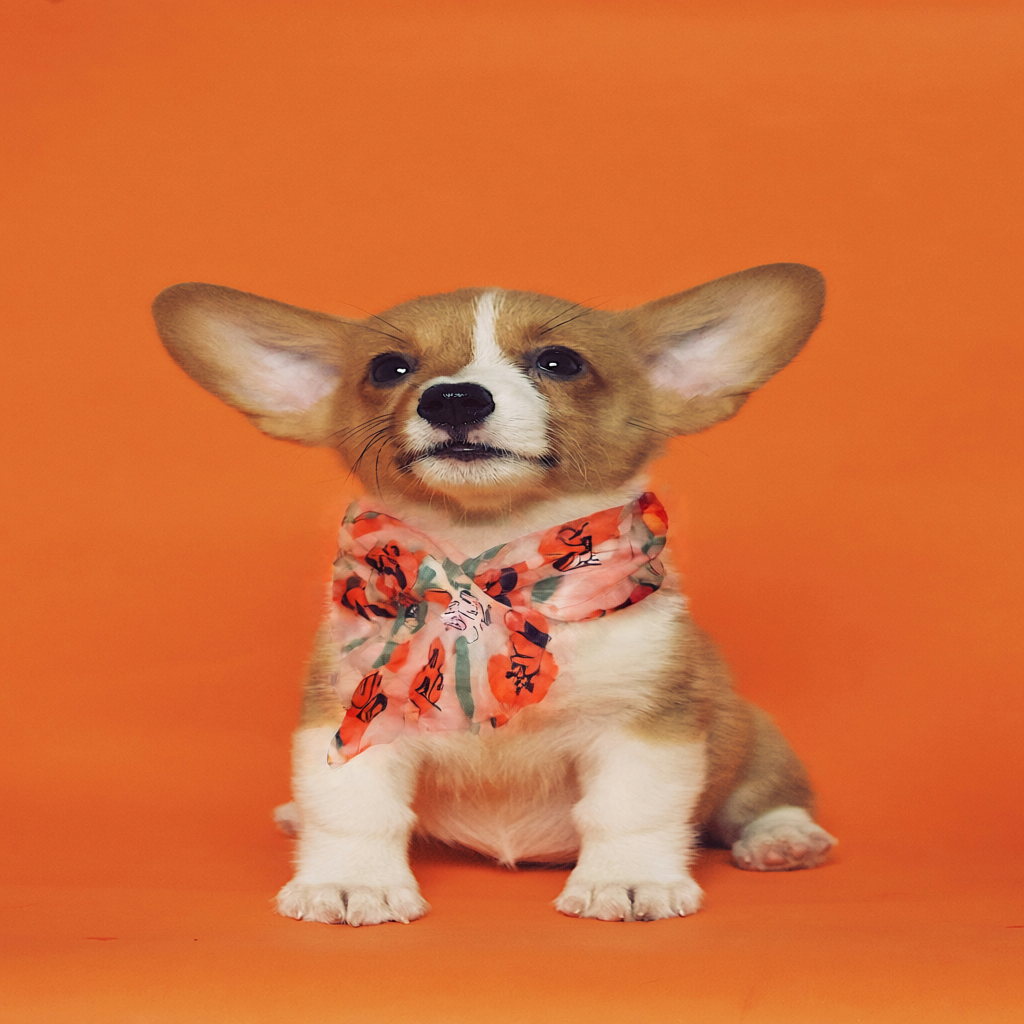

In [6]:
aux = {}
res = generate(
    pipe,
    image = image,                 # single image, or a list for multi-reference editing
    prompt = 'add a scarf to the dog',
    config = config,
    aux = aux,
    num_inference_steps=50,        # both 2509 and 2511
    guidance_scale=1.0,            # 2511: 1.0 (with true_cfg_scale=4.0); omit for 2509
)
res.images[0]

## No SpotEdit (baseline)
The same `generate()` with caching disabled (`initial_steps` > steps → full compute every step) — a fair same-code-path reference. SpotEdit should match this closely.

true_cfg_scale is passed as 4.0, but classifier-free guidance is not enabled since no negative_prompt is provided.


guidance_scale is passed as 1.0, but ignored since the model is not guidance-distilled.


  0%|          | 0/50 [00:00<?, ?it/s]

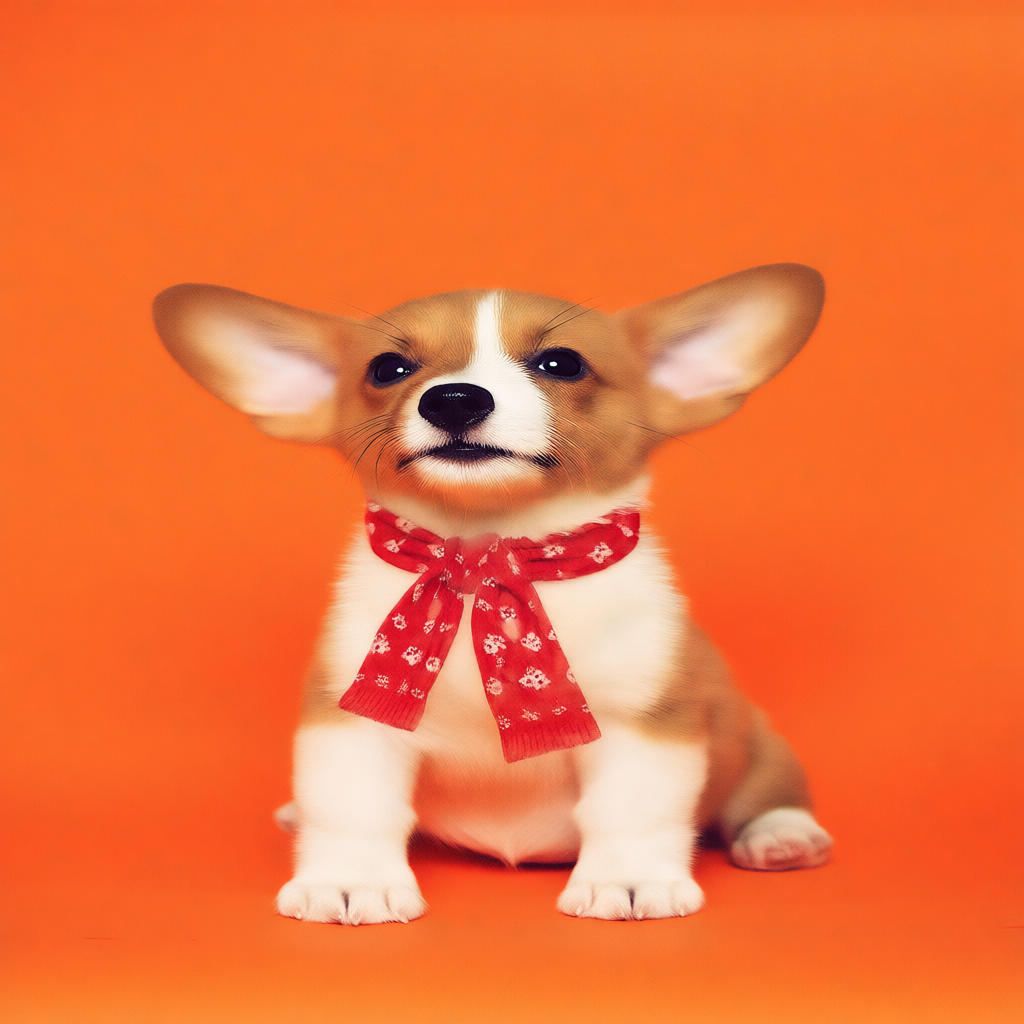

In [7]:
base = generate(
    pipe,
    image = image,
    prompt = 'add a scarf to the dog',
    config = SpotEditConfig(initial_steps=51),   # > num_inference_steps -> no reuse
    num_inference_steps=50,
    guidance_scale=1.0,
)
base.images[0]

## Reuse region
The cached (non-edited) tokens SpotEdit skipped are tinted; full-colour = the recomputed (edited) region. The reuse decision is made against the first reference image.

reused 93% of tokens (tinted region)


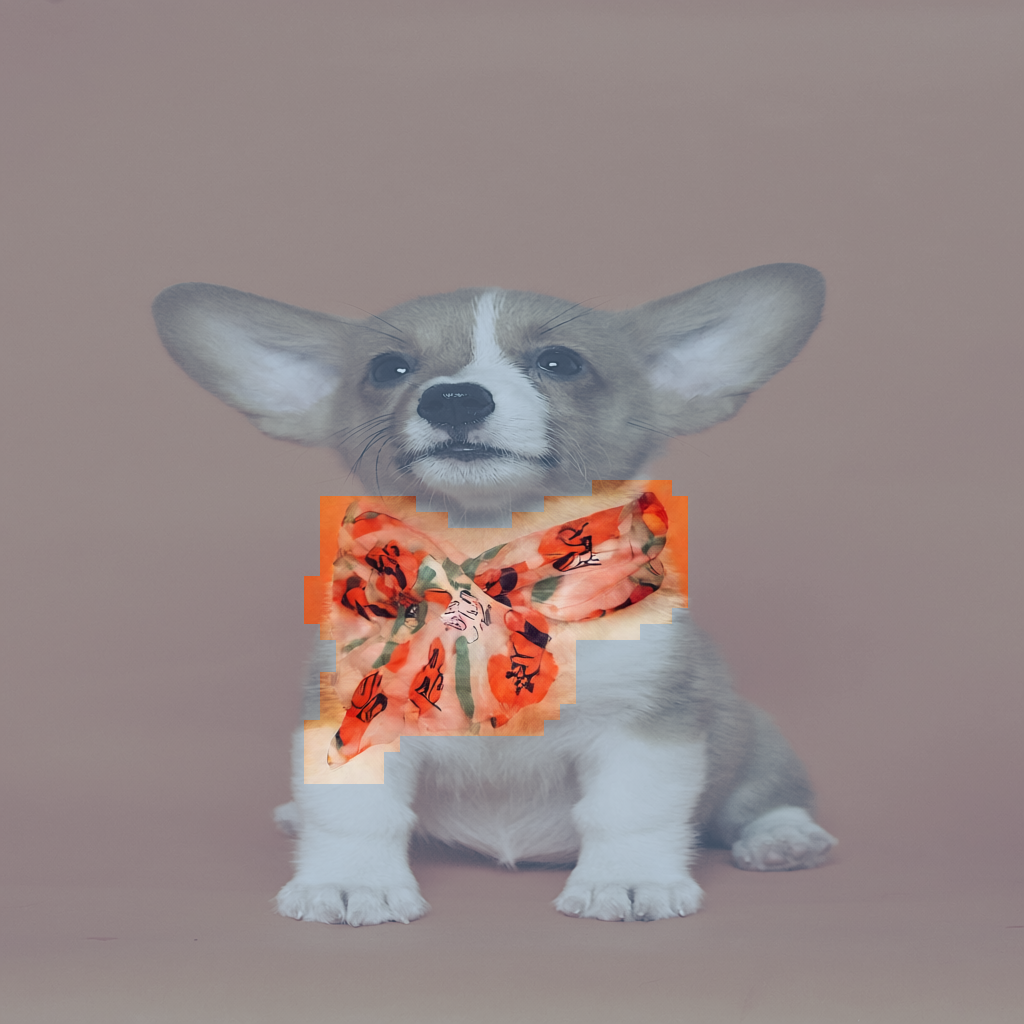

In [8]:
import numpy as np
from PIL import Image

def show_reuse(result_img, aux):
    """Tint the cached (reused, non-edited) tokens; full-colour = recomputed (edited) region."""
    m = aux['reuse_mask'].numpy().reshape(aux['H_lat'], aux['W_lat'])
    img = np.asarray(result_img.convert('RGB')).astype(np.float32)
    H, W, _ = img.shape
    up = np.asarray(Image.fromarray((m * 255).astype('uint8')).resize((W, H), Image.NEAREST)).astype(np.float32) / 255.0
    up = up[..., None]
    gray = img.mean(2, keepdims=True)
    tint = (0.45 * img + 0.55 * gray) * 0.6 + np.array([120, 165, 205], np.float32) * 0.4
    return Image.fromarray((img * (1 - up) + tint * up).clip(0, 255).astype('uint8'))

print(f"reused {float(aux['reuse_mask'].float().mean()) * 100:.0f}% of tokens (tinted region)")
show_reuse(res.images[0], aux)

Qwen-Image-Edit-Plus also accepts **multiple reference images** (pass a list). SpotEdit makes its reuse decision against the *first* image (the edit target); any extra references are kept as always-cached context. Use square 1024x1024 inputs for best results.

In [9]:
# image2 = load_image('./asset/other.jpg').resize((1024, 1024))
# res = generate(
#     pipe,
#     image = [image, image2],
#     prompt = 'put the hat from the second image on the dog',
#     config = config,
#     num_inference_steps=50,
# )
# res.images[0]